# Test Merging Datasets

In [6]:
import xarray as xr
import numpy as np

In [25]:
ds = xr.Dataset(
    {"var": (["x", "y"], np.array([[0, 0, 0], [1, 1, 1], [2, 2, 2]], dtype="float"))},
    coords={"x": np.arange(3), "y": np.arange(3)},
)

In [26]:
ds["var"]

<xarray.DataArray 'var' (x: 3, y: 3)> Size: 72B
array([[0., 0., 0.],
       [1., 1., 1.],
       [2., 2., 2.]])
Coordinates:
  * x        (x) int64 24B 0 1 2
  * y        (y) int64 24B 0 1 2

In [9]:
import matplotlib.pyplot as plt

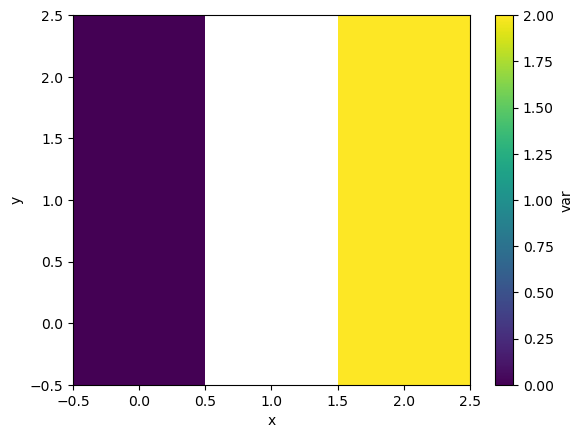

In [23]:
ds["var"].plot(x="x", y="y")

In [27]:
ds_1 = ds.copy(deep=True).sel(x=slice(0, 1))
ds_2 = ds.copy(deep=True).sel(x=slice(1, 1))
ds_3 = ds.copy(deep=True).sel(x=slice(1, 2))

In [28]:
ds_2["var"].loc[{"y": [0, 2]}] = np.nan
ds_2["var"]

<xarray.DataArray 'var' (x: 1, y: 3)> Size: 24B
array([[nan,  1., nan]])
Coordinates:
  * x        (x) int64 8B 1
  * y        (y) int64 24B 0 1 2

In [30]:
ds_1["var"].loc[{"x": [1, 1], "y": [1, 2]}] = np.nan
ds_1["var"]

<xarray.DataArray 'var' (x: 2, y: 3)> Size: 48B
array([[ 0.,  0.,  0.],
       [ 1., nan, nan]])
Coordinates:
  * x        (x) int64 16B 0 1
  * y        (y) int64 24B 0 1 2

In [31]:
ds_3["var"].loc[{"x": [1, 1], "y": [0, 1]}] = np.nan
ds_3["var"]

<xarray.DataArray 'var' (x: 2, y: 3)> Size: 48B
array([[nan, nan,  1.],
       [ 2.,  2.,  2.]])
Coordinates:
  * x        (x) int64 16B 1 2
  * y        (y) int64 24B 0 1 2

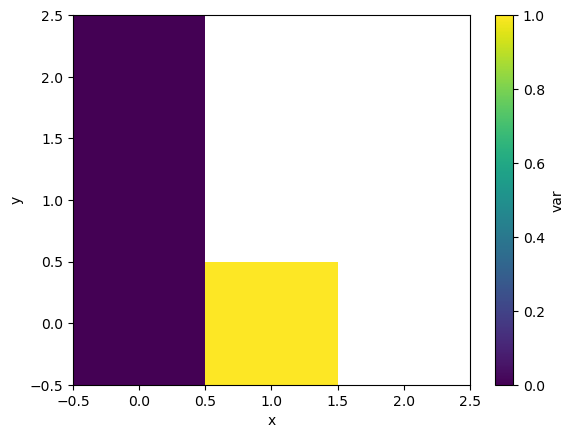

In [42]:
xr.merge([ds_1, ds_2, ds_3], compat="override", join="outer")["var"].plot(x="x", y="y")

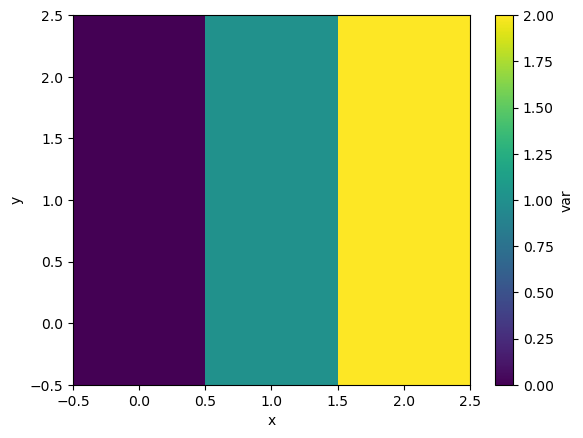

In [44]:
ds_1.combine_first(ds_2).combine_first(ds_3)["var"].plot(x="x", y="y")

In [45]:
def merge_by_combine(dset: xr.Dataset, *dsets: xr.Dataset) -> xr.Dataset:
    """Combine all datasets to a new one. Assume"""
    if not dsets:
        return dset
    for ds_right in dsets:
        dset = dset.combine_first(ds_right)
    return dset

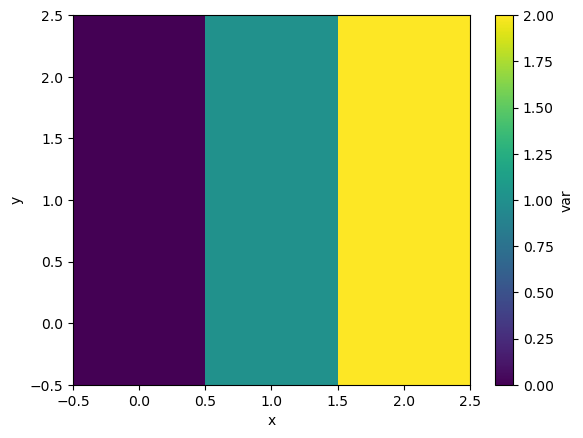

In [46]:
merge_by_combine(ds_2, ds_1, ds_3)["var"].plot(x="x", y="y")